# **NASA's Turbofan Jet Engine Predictive Maintenance System**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

In [35]:
raw_data = pd.read_csv('train_FD004.txt', sep=' ', header = None)

In [36]:
raw_data = raw_data.drop([26,27], axis='columns')

In [37]:
raw_data.columns = ['ID', 'Cycle', 'OpSet1', 'OpSet2', 'OpSet3', 'SensorMeasure1', 'SensorMeasure2', 'SensorMeasure3', 'SensorMeasure4', 'SensorMeasure5', 'SensorMeasure6', 'SensorMeasure7', 'SensorMeasure8', 'SensorMeasure9', 'SensorMeasure10', 'SensorMeasure11', 'SensorMeasure12', 'SensorMeasure13', 'SensorMeasure14', 'SensorMeasure15', 'SensorMeasure16', 'SensorMeasure17', 'SensorMeasure18', 'SensorMeasure19', 'SensorMeasure20', 'SensorMeasure21']

In [ ]:
raw_data[raw_data['ID'] == 1]

In [39]:
EOL=[]
for sl_no in raw_data['ID']:
        EOL.append( ((raw_data[raw_data['ID'] == sl_no]["Cycle"]).values)[-1])

In [40]:
np.shape(EOL)

(61249,)

In [41]:
raw_data["EOL"]=EOL

# Defining the labels
Here we will define the engine's condition with Life Ratio (LR), which is the ratio between Current Cycle and the End cycle/ End of Life(EOL). If LR=0, that means the component has just started its degradation and LR=1 means, it is completely degraded.

* if LR <= 0.6 - Good Condition

* if 0.6 < LR <= 0.8 - Moderate Condition
* if 0.8 < LR - Warning Condition

In [42]:
raw_data["LR"] = raw_data["Cycle"].div(raw_data["EOL"])

In [43]:
raw_data=raw_data.drop(columns=['ID','EOL'])

In [44]:
labels=[]
for i in range (0,len(raw_data)):
    if np.array(raw_data["LR"])[i] <= 0.6:
        labels.append(0)
    elif np.array(raw_data["LR"])[i] <= 0.8 :
        labels.append(1)
    else :
        labels.append(2)

raw_data["labels"]=labels
raw_data  = raw_data.drop(columns=['LR'])

# Making Training Data-set

In [45]:
raw_data.to_csv('Training_4_all_features.csv', index=None)

In [46]:
df1 = pd.read_csv('Training_1_all_features.csv')
df2 = pd.read_csv('Training_2_all_features.csv')
df3 = pd.read_csv('Training_3_all_features.csv')
df4 = pd.read_csv('Training_4_all_features.csv')

In [47]:
df = pd.concat([df1,df2,df3,df4])

In [49]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.10, random_state = 0)

In [52]:
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier()
RF.fit(X_train, y_train)

RandomForestClassifier()

# Performance on Validation set

0.8934350581431121

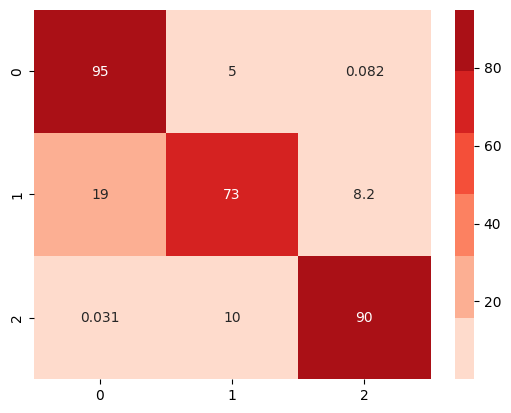

In [53]:
y_pred_RF = RF.predict(X_test)

cm = pd.DataFrame(confusion_matrix(y_test, y_pred_RF, normalize ='true')*100)
colormap = sns.color_palette("Reds")
sns.heatmap(cm, annot=True,cmap=colormap)

accuracy_score(y_test, y_pred_RF)

In [54]:
RF.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

# Performance on Training set

1.0

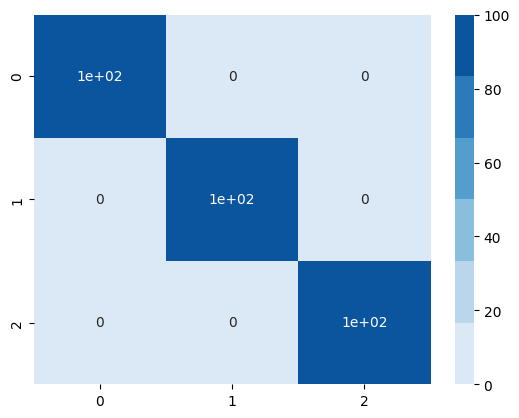

In [55]:
y_pred_RF = RF.predict(X_train)

cm = pd.DataFrame(confusion_matrix(y_train, y_pred_RF, normalize ='true')*100)
colormap = sns.color_palette("Blues")
sns.heatmap(cm, annot=True,cmap=colormap)

accuracy_score(y_train, y_pred_RF)

# Randomized Search with cross validation for Hyperparameter optimization

In [56]:
from sklearn.model_selection import RandomizedSearchCV
n_estimators=[200, 400, 300]
max_depth= [10, 20, 30]
max_samples= [0.2,0.3,0.4 ]

random_grid = {'n_estimators': n_estimators,
               'max_depth': max_depth,
               'max_samples': max_samples}
print(random_grid)

{'n_estimators': [200, 400, 300], 'max_depth': [10, 20, 30], 'max_samples': [0.2, 0.3, 0.4]}


In [57]:
rf = RandomForestClassifier()
rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, cv = 3,n_jobs=-1)
rf_random.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30],
                                        'max_samples': [0.2, 0.3, 0.4],
                                        'n_estimators': [200, 400, 300]})

In [58]:
rf_random.best_params_

{'n_estimators': 300, 'max_samples': 0.4, 'max_depth': 30}

In [59]:
rf_random.best_score_

np.float64(0.8914290419852294)

0.8928197871162247

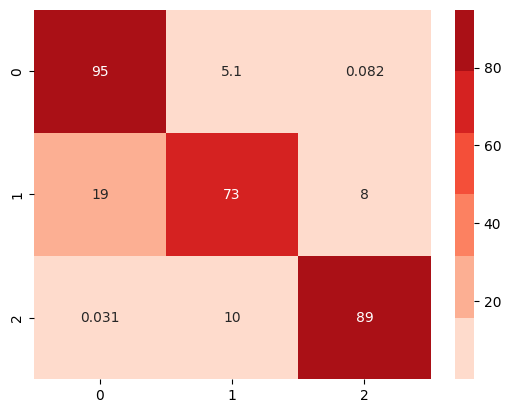

In [60]:
RF_randSer = RandomForestClassifier(n_estimators=300,max_samples=0.4,max_depth= 20)
RF_randSer.fit(X_train, y_train)
y_pred_RF = RF_randSer.predict(X_test)

cm = pd.DataFrame(confusion_matrix(y_test, y_pred_RF, normalize ='true')*100)
colormap = sns.color_palette("Reds")
sns.heatmap(cm, annot=True,cmap=colormap)

accuracy_score(y_test, y_pred_RF)

# Prediction on Test Dataset

In [94]:
raw_data = pd.read_csv('test_FD004.txt', sep=' ', header = None)
raw_data = raw_data.drop([26,27], axis='columns')
raw_data.columns = ['ID', 'Cycle', 'OpSet1', 'OpSet2', 'OpSet3', 'SensorMeasure1', 'SensorMeasure2', 'SensorMeasure3', 'SensorMeasure4', 'SensorMeasure5', 'SensorMeasure6', 'SensorMeasure7', 'SensorMeasure8', 'SensorMeasure9', 'SensorMeasure10', 'SensorMeasure11', 'SensorMeasure12', 'SensorMeasure13', 'SensorMeasure14', 'SensorMeasure15', 'SensorMeasure16', 'SensorMeasure17', 'SensorMeasure18', 'SensorMeasure19', 'SensorMeasure20', 'SensorMeasure21']

In [95]:
given_no_of_cycles=[]
for i in range (1,len(raw_data['ID'].unique())+1):
    given_no_of_cycles.append(len(raw_data[raw_data['ID']==i]))
    print(len(raw_data[raw_data['ID']==i]))

given_no_of_cycles=np.array(given_no_of_cycles).reshape([cycle_ran_after.shape[0],1])

230
153
141
208
51
146
54
248
284
23
82
270
227
102
168
240
334
247
24
115
202
158
162
174
486
90
144
20
216
229
134
260
107
361
278
159
345
125
214
266
414
200
120
406
78
37
224
214
273
206
137
58
67
81
103
180
121
185
37
135
396
240
158
251
186
97
150
241
162
190
292
118
149
223
203
48
108
106
184
112
60
146
274
88
174
254
167
140
285
118
144
116
200
105
110
123
51
82
237
196
166
443
145
65
351
148
121
145
66
348
342
88
132
218
82
161
97
178
228
170
194
117
236
230
21
220
98
139
315
107
193
115
74
266
435
56
291
239
88
160
19
69
327
34
102
84
116
126
320
202
285
195
130
122
161
28
138
171
160
122
257
99
122
29
178
63
99
74
34
48
355
132
151
135
116
185
146
279
262
367
199
98
125
154
203
47
121
157
107
200
71
203
263
214
186
70
196
115
177
115
139
222
87
19
95
291
179
180
171
135
206
261
288
102
72
264
141
63
110
65
176
178
305
152
39
59
62
126
20
157
230
370
111
179
362
176
221
177
28
204
42
112
199
184
63
29
94
281


ValueError: cannot reshape array of size 248 into shape (100,1)

In [96]:
len(raw_data['ID'].unique())

248

In [97]:
cycle_ran_after = pd.read_csv('RUL_FD004.txt', sep=' ', header = None)
cycle_ran_after=cycle_ran_after.drop([1], axis='columns')
cycle_ran_after = np.array(cycle_ran_after)

In [98]:
EOL=[]
i=0

for i in raw_data['ID']:
        EOL.append(given_no_of_cycles[i-1]+cycle_ran_after[i-1] )

EOL = np.array(EOL).reshape([len(EOL),1])

In [99]:
EOL.shape

(41214, 1)

In [100]:
raw_data['EOL']=EOL

In [101]:
raw_data["LR"] = raw_data["Cycle"].div(raw_data["EOL"])
raw_data=raw_data.drop(columns=['ID','EOL'])

In [102]:
labels=[]
for i in range (0,len(raw_data)):
    if np.array(raw_data["LR"])[i] <= 0.6:
        labels.append(0)
    elif np.array(raw_data["LR"])[i] <= 0.8 :
        labels.append(1)
    else :
        labels.append(2)

raw_data["labels"]=labels
raw_data  = raw_data.drop(columns=['LR'])

In [103]:
raw_data.to_csv('Test_classification_4.csv', index=None)

In [104]:
df1 = pd.read_csv('Test_classification_1.csv')
df2 = pd.read_csv('Test_classification_2.csv')
df3 = pd.read_csv('Test_classification_3.csv')
df4 = pd.read_csv('Test_classification_4.csv')

test_df = pd.concat([df1,df2,df3,df4])

X_test = test_df.iloc[:,0:-1]
y_test = test_df.iloc[:,-1]

0.9070802787496306

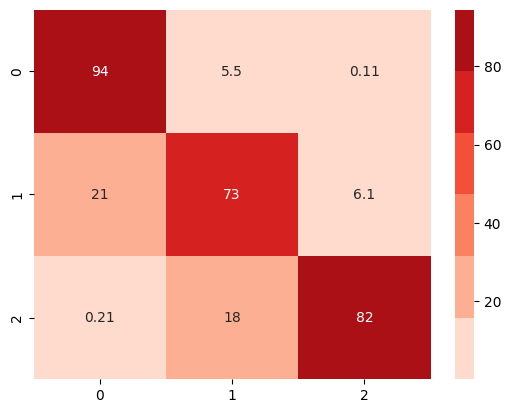

In [106]:
feature_columns = X_train.columns
X_test_corrected = test_df[feature_columns]
y_test_corrected = test_df['labels']

y_pred_RF = RF_randSer.predict(X_test_corrected)

cm = pd.DataFrame(confusion_matrix(y_test_corrected, y_pred_RF, normalize ='true')*100)
colormap = sns.color_palette("Reds")
sns.heatmap(cm, annot=True,cmap=colormap)

accuracy_score(y_test_corrected, y_pred_RF)